# Python Peer-to-Peer Energy Sharing Optimization Library (PyPESOL)

<img src="logo.png" width=100 height=100 />

## A Brief Getting Started Guide

This simple guide allows to get started with PyPESOL. Let's illustrate the functionalities of the optimizer on a small example provided in the folder **data_test**. The data provided as part of this tiny example is purely arbitrary.

Let's first start by initializing an optimizer based on the data in that folder.

In [2]:
# matplotlib wird zum Plotten importiert
from matplotlib import pyplot as plt

# der Inhalt von optimizer.py wird geladen. Dort befindet sich insbesondere die Klasse Optimizer, die wir gleich verwenden werden.
from optimizer import *

plt.rcParams["figure.figsize"] = (16,4)

# Hier wird ein neues Optimizer-Objekt erstellt und in der Variable opt gespeichert, das die Daten aus dem Ordner "data_test" lädt. 
opt = Optimizer.from_folder2("data_test")

print("OK, optimizer loaded in memory!")

OK, optimizer loaded in memory!


The optimizer is built to calculates the (optimal) electricity cost of a set of end-users. It relies on 5 types of data and a few constant values:
- $B_u$ the battery capacity (kWh) of user u (for all users)
- $PV_u$ the PV capacity (kWp) of user u (for all users)
- $cons(u,t)$ the hourly consumption profile (kWh) of user $u$ over a certain time period $t \in T$
- $sun(u,t)$ the solar profile (kWh/kWp) of user $u$ over a certain time period $t \in T$; alternatively, this can be directly the electricity generation of user $u$ when setting $PV_u = 1$
- $price(t)$ the price (e.g. in €/kWh) over the time period $t \in T$ (assumed the same for all users)
- $tax$ the level of tax
- $el_{tax}$ added tax (e.g. in €/kWh) on top of market price when buying from the grid
- $el_{net}$ added benefit (e.g. in €/kWh) on top of market price when selling to the grid

auf Deutsch:

| Variable | Bedeutung | Einheit |
|---|---|---|
| $B_u$ | Batteriekapazität von Nutzer $u$ | kWh |
| $PV_u$ | installierte PV-Leistung | kWp |
| $cons(u,t)$ | Zeitreihe des Verbrauchs vom Nutzer $u$ | kWh |
| $sun(u,t)$ | Zeitreihe der spezifischer PV-Erzeugung | kWh/kWp |
| $price(t)$ | Strompreis (Zeitreihe) | z. B. €/kWh |
| $tax$ | Steuerfaktor des Stroms | – |
| $el_tax$ | Netzentgelte | z. B. €/kWh |
| $el_net$ | Vergütung/Bonus bei Einspeisung oder Marktprämie | z. B. €/kWh |

Let's inspect the example data. It contains 4 users: the first one is a prosumer with a battery of 10 kWh and a PV capacity of 5 kWp, while the 3rd user has a battery of 5 kWh and PV capacity of 2 kWp. The second and fourth ones are usual consumers that has no resource. The variables `opt.battery` and `opt.pv` are arrays stroing the battery and PV capacities for all users $u_1, \dots, u_n$:

| User | 0 | 1 | 2 | 3 |
|---|---:|---:|---:|---:|
| Battery (kWh) | 10 | 0 | 5 | 0 |
| PV (kWp) | 5 | 0 | 2 | 0 |
| Role | Prosumer | Consumer | Prosumer | Consumer |


##### INPUT 1: Batteriekapazität von Nutzer $u$

In [3]:
opt.battery

array([10.,  0.,  5.,  0.])

##### INPUT 2: installierte PV-Leistung von Nutzer $u$

In [4]:
opt.pv

array([5., 0., 2., 0.])

######  Battery and PV Data

The arrays below describe the battery capacity and PV capacity for each user.

- `opt.battery` → battery capacity in **kWh**
- `opt.pv` → PV capacity in **kWp**

| User | Battery (kWh) | PV capacity (kWp) | Role |
|-----|---------------|-------------------|------|
| 0 | 10 | 5 | Prosumer |
| 1 | 0 | 0 | Consumer |
| 2 | 5 | 2 | Prosumer |
| 3 | 0 | 0 | Consumer |

##### INPUT 3: Zeitreihe des Verbrauchs vom Nutzer $u$

Consumptions are stored in the 2d-array `opt.cons` where $cons(u,t) =$ `opt.cons[u][t]`. In the example data, 3 days of data are stored. Let's have a first look at the consumptions of the two users:
In the diagram given below,
Mg= Morning time,
Non=Noon,
Ev=Evening,
Nt=Night

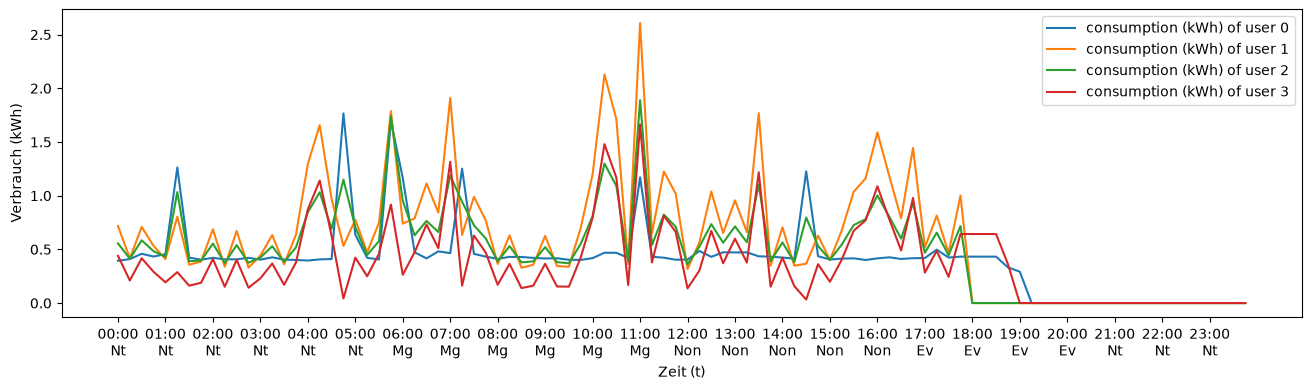

In [12]:
plt.plot(opt.cons[0], label='consumption (kWh) of user 0')
plt.plot(opt.cons[1], label='consumption (kWh) of user 1')
plt.plot(opt.cons[2], label='consumption (kWh) of user 2')
plt.plot(opt.cons[3], label='consumption (kWh) of user 3')

plt.xlabel('Zeit (t)')
plt.ylabel('Verbrauch (kWh)')

# 4 Zeitschritte x 15 min = 60 min = 1 h, daher werden die xticks alle 4 Zeitschritte gesetzt
ticks = list(range(0, len(opt.cons[0]), 4))

# Define labels based on time of day
labels = []
for t in ticks:
    hour = (t // 4) % 24  # Assuming each time step represents 15 minutes
    if 6 <= hour < 12:
        labels.append(f"{hour:02d}:00\nMg")
    elif 12 <= hour < 17:
        labels.append(f"{hour:02d}:00\nNon")
    elif 17 <= hour < 21:
        labels.append(f"{hour:02d}:00\nEv")
    else:
        labels.append(f"{hour:02d}:00\nNt")

plt.xticks(ticks, labels)

plt.legend()
plt.show()

##### INPUT 4: Zeitreihe der spezifischer PV-Erzeugung

Mit 15min-Auflösung sieht opt.sun so aus:

In [6]:
opt.sun[0][0]   # 00:00
opt.sun[0][1]   # 00:15
opt.sun[0][2]   # 00:30
opt.sun[0][3]   # 00:45
opt.sun[0][4]   # 01:00

np.float64(0.0)

PV-Profile: Solar profiles are stored in the 2d-array `opt.sun`:

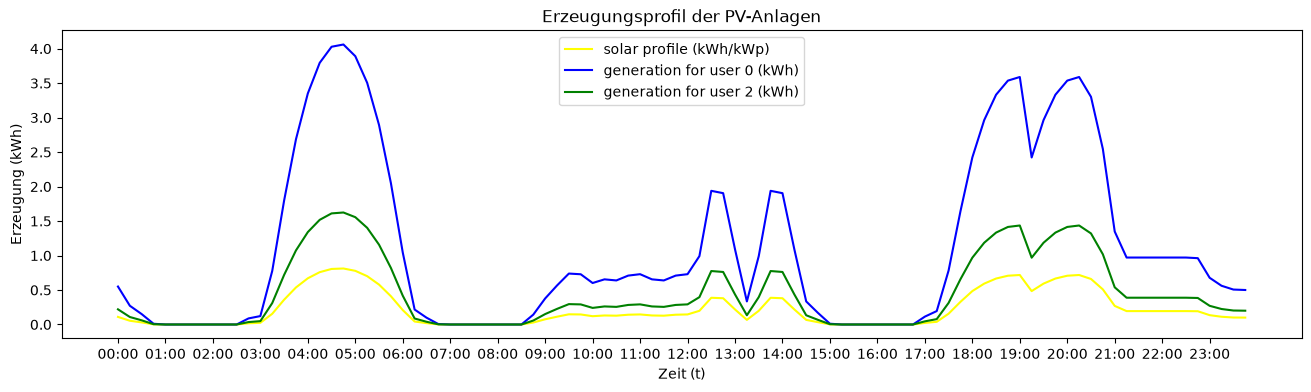

In [11]:
plt.plot(opt.sun[0], label='solar profile (kWh/kWp)', color='yellow')

for user, coluser in zip([0,2],['blue','green']):
    # für jeden Wert s aus dem Solarprofil wird die PV-Leistung des jeweiligen Users multipliziert, um die tatsächliche Erzeugung zu erhalten
    # für User 0 beispielsweise: opt.pv[0] = 5
    # also
    # 5 × sun[0][0]
    # 5 × sun[0][1]
    # 5 × sun[0][2]
    # Dadurch entsteht eine Liste von Werten, die die tatsächliche Erzeugung des Users 0 zu jedem Zeitpunkt darstellen.
    plt.plot([opt.pv[user]*s for s in opt.sun[0]],
             label=f'generation for user {user} (kWh)',
             color=coluser)

plt.xlabel("Zeit (t)")
plt.ylabel("Erzeugung (kWh)")
plt.title("Erzeugungsprofil der PV-Anlagen")

ticks = list(range(0, len(opt.sun[0]), 4))
labels = []

for t in ticks:
    hour = (t // 4) % 24
    labels.append(f"{hour:02d}:00")

plt.xticks(ticks, labels)
plt.legend()
plt.show()

##### INPUT 5: Zeitreihe des Strompreises

The last input is the hourly-dependent electricity prices:

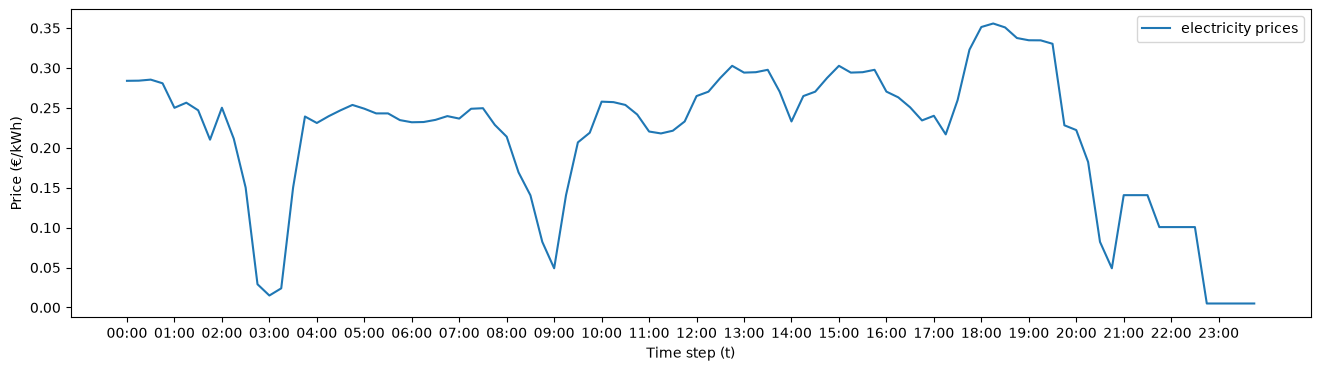

In [8]:
from matplotlib import pyplot as plt

plt.plot(opt.price, label='electricity prices')

plt.xlabel('Time step (t)')
plt.ylabel('Price (€/kWh)')
plt.xticks(ticks, labels)
plt.legend()
plt.show()

In [ ]:
print(len(opt.price)) #96
print(len(opt.cons[0])) #96

96
96


For prosumers equipped with a battery system, one can call `opt.optimize(u)` to calculate the best usage of the battery over the time period. The optimization decides how much electricity should be imported from the grid, exported to the grid, and stored or discharged from the battery, while satisfying system constraints such as energy balance and battery limits.

Der Ansatz `opt.optimize(u)` bedeutet vereinfacht: „Optimiere den Energieeinsatz von User $u$ über den gesamten betrachteten Zeitraum so, dass seine Stromkosten minimal werden.“

The total cost is calculated using the following objective function:

##### Optimal Cost Minimization

The main objective is to minimize the electricity cost:

$$
\text{Optimal Cost} = \min \sum_{t=1}^{T} \big[ el\_in(t) \cdot (price(t) \cdot tax + el\_tax) - el\_out(t) \cdot (price(t) + el\_net) \big]
$$

 Explanation of Terms

- `el_in(t)` = electricity imported from the grid at time t  
- `price(t)` = electricity market price at time t  
- `tax` = percentage tax on imported electricity  
- `el_tax` = fixed electricity tax per kWh
-  `el_out(t)` = electricity exported to the grid at time t 
- `el_net` = small credit/bonus for selling electricity  
- `T` = total number of time steps (hours)
  
The function returns the calculated cost over the period considering the battery level follows the calculated decisions:

optimal cost is -1.06021


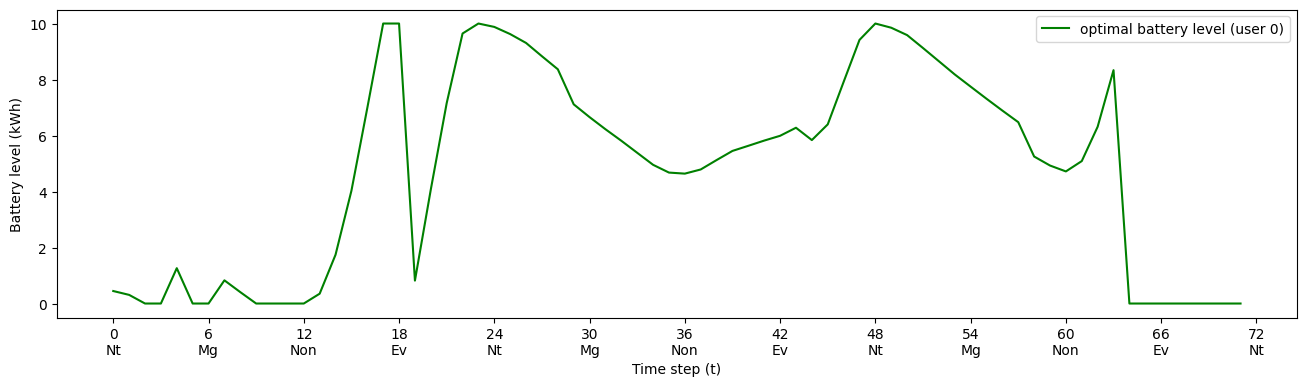

In [8]:
print("optimal cost is", opt.optimize(0))

plt.plot(opt.bat, label='optimal battery level (user 0)', color="green")

plt.xlabel('Time step (t)')
plt.ylabel('Battery level (kWh)')
plt.xticks(ticks, labels)
plt.legend()

optimal cost is 1.84891


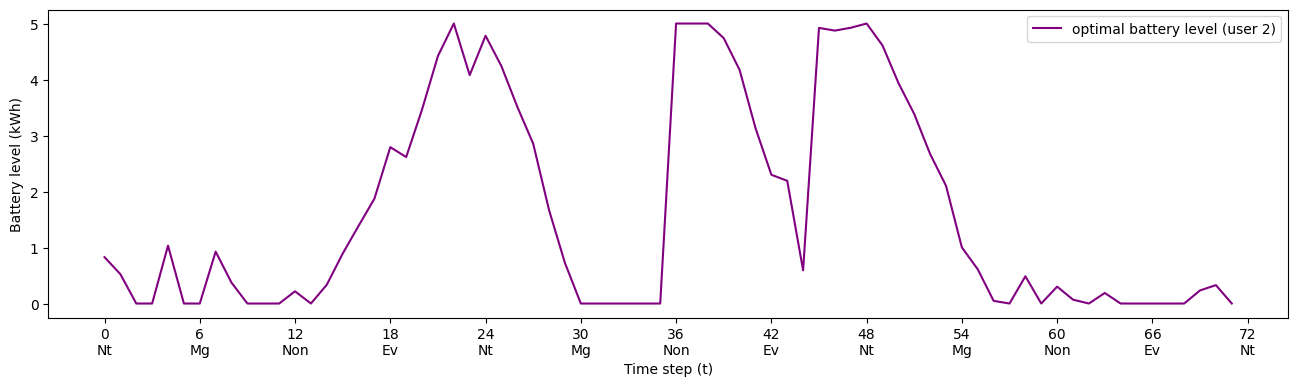

In [9]:
print("optimal cost is", opt.optimize(2))
plt.plot(opt.bat, label='optimal battery level (user 2)', color="purple")

plt.xlabel('Time step (t)')
plt.ylabel('Battery level (kWh)')
plt.xticks(ticks, labels)
plt.legend()

For users without a battery `optimize` is resolved without claling the LP-solver and just iterating over the input. Interactions with the grid is retrieved in `opt.el_in` and `opt.el_out`. For users without PV panels, all electricity is bought from the grid.

cost of user 1 is 5.879356283625002


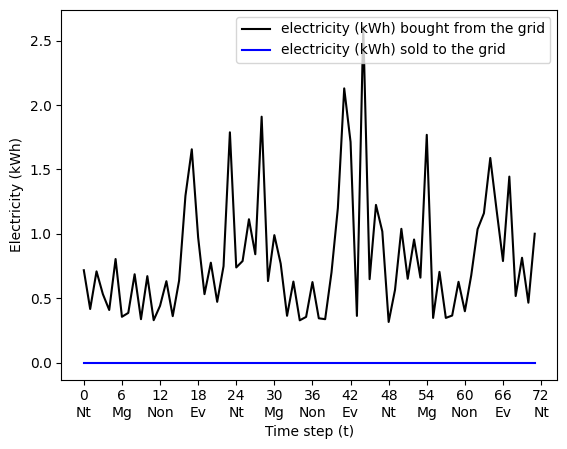

In [10]:
print("cost of user 1 is", opt.optimize(1))

plt.plot(opt.el_in, label="electricity (kWh) bought from the grid", color="black")
plt.plot(opt.el_out, label="electricity (kWh) sold to the grid", color="blue")

plt.xlabel("Time step (t)")
plt.ylabel("Electricity (kWh)")

ticks = list(range(0, 73, 6))

labels = []
for t in ticks:
    hour = t % 24
    if 6 <= hour < 12:
        labels.append(f"{t}\nMg")
    elif 12 <= hour < 17:
        labels.append(f"{t}\nNon")
    elif 17 <= hour < 21:
        labels.append(f"{t}\nEv")
    else:
        labels.append(f"{t}\nNt")

plt.xticks(ticks, labels)

plt.legend()

## Group Optimization
To optimize the two users as a group, one can combine their consumptions (aggregate model) and optimize their coordinated decisions:

In [23]:
cost_community = opt.optimize_community((1,3))
print(cost_community)

9.373646697187498


In this scenario, the base individual cost is equal to -1.06021 (for user 0) + 5.879356283625002 (for user 1):

In [26]:
cost_individual = opt.subset((1,3)).optimize()
print(cost_individual)

9.373646697187501


Hence, working as a group, the users gain a profit of:

In [27]:
cost_individual-cost_community

np.float64(3.552713678800501e-15)

## Example of Matching Calculations

Let's take the data we use in the small example above and illustrate how one can calculate the best matching into 2 communities, each containing 1 prosumer and 1 consumer.

Here below a **random matching** (Assigns consumers to prosumers randomly without considering cost savings) is produced.

In [29]:
from matching import *
random_matching(opt)

defaultdict(list, {0: [3], 2: [1]})

Next, one can calculate the **"naive" matching** (matched each prosumer with first available consumers) as follows:

In [30]:
naive_matching(opt, 2)

defaultdict(list, {0: [1, 3], 2: []})

Here below how to calculate the **optimal matching** (Finds the pairing that maximizes total cost savings by evaluating all possible combinations.):Here 'weight' represents the cost savings obtained when two users are grouped together. 

In [32]:
weights = calculate_all_pairwise_weights(opt)
optimal_pairwise_matching(opt, 2, weights)

defaultdict(list, {0: [1], 2: [3]})

The **SinglePass matching**  goes through the prosumers and assign the k-1 consumers with best benefits (weights are calculated on the fly and memoized):

In [33]:
weights = memoized_weights(opt)
singlepass_matching(opt, 2, weights)

defaultdict(list, {0: [1], 2: [3]})

With WB, consumers are sorted in decreasing order, then **Round Robin** assigns them cyclically across prosumers,iterating in turns and allocating one consumer at a time.

In [34]:
weights = calculate_all_pairwise_weights(opt)
round_robin_matching(opt, 2, weights)

defaultdict(list, {2: [1], 0: [3]})

**Classic greedy** computes all weights first, then repeatedly picks the best available matches until constraints are satisfied.

In [35]:
weights = calculate_all_pairwise_weights(opt)
classic_greedy_matching(opt, 2, weights)

defaultdict(list, {0: [1], 2: [3]})